## NB4

## Load the libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## upload the dataset

In [2]:
rfm = pd.read_csv("C:/Projects/08_Customer_Intellignece_System/data/customer_segments.csv")
rfm.head()

,Unnamed: 0,CustomerID,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,Cluster
0,0,12346.0,326,1,77183.60,5.789960,0.693147,11.253955,2
1,1,12347.0,2,7,4310.00,1.098612,2.079442,8.368925,1
2,2,12348.0,75,4,1797.24,4.330733,1.609438,7.494564,2
3,3,12349.0,19,1,1757.55,2.995732,0.693147,7.472245,0
4,4,12350.0,310,1,334.40,5.739793,0.693147,5.815324,3


## (1) Analyze each cluster

In [3]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency' : 'mean',
    'Frequency' : 'mean',
    'Monetary' : 'mean'
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,18.12,2.15,551.82
1,12.13,13.71,8074.27
2,71.08,4.08,1802.83
3,182.50,1.32,343.45


## (2) Label clusters

In [4]:
def label_cluster(row):
    if row['Recency'] < 50 and row['Monetary'] > 500:
        return 'Champions'
    elif row['Frequency'] > 10:
        return 'Loyal Customers'
    elif row['Recency'] > 200:
        return 'At Risk'
    else:
        return 'Potential Customers'

rfm['Segment'] = rfm.apply(label_cluster, axis=1)

## (3) Check Segment Distribution

In [5]:
rfm['Segment'].value_counts()

Segment
Potential Customers    1973
Champions              1605
At Risk                 742
Loyal Customers          18
Name: count, dtype: int64

## (5) Visualize segments

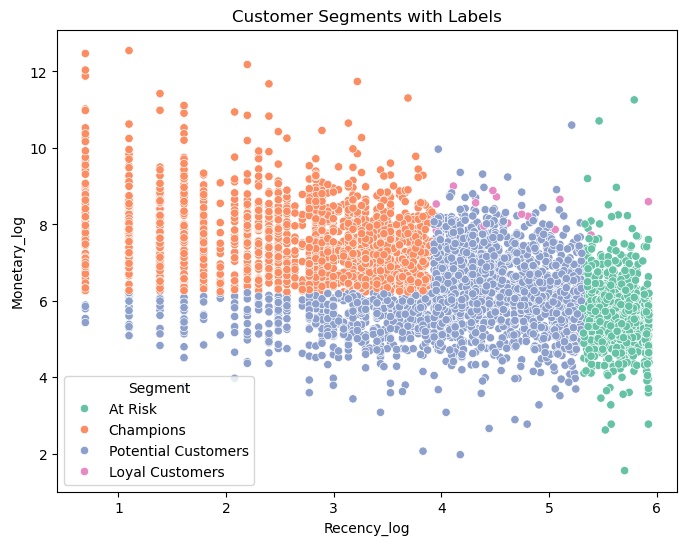

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=rfm['Recency_log'],
    y=rfm['Monetary_log'],
    hue=rfm['Segment'],
    palette='Set2'
)
plt.title("Customer Segments with Labels")
plt.show()

## (7) Save the final dataset

In [11]:
rfm.to_csv("C:/Projects/08_Customer_Intellignece_System/data/final_customer_segments.csv", index=False)